# O.L.A.F. Capstone: Hypothesis Test + Regression


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path



class AoI:
    def __init__(self, lat_min, lat_max, lon_min, lon_max):
        self.lat_min = float(lat_min)
        self.lat_max = float(lat_max)
        self.lon_min = float(lon_min)
        self.lon_max = float(lon_max)

USE_COLS = [
    "MMSI", "VesselName", "BaseDateTime",
    "LAT", "LON", "SOG", "COG",
    "Status", "TransceiverClass"
]

def _find_data_path(filename="Florida_Routes.csv"):
    """Find data/Florida_Routes.csv whether the notebook is run from repo root or from scripts/."""
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / filename,
        cwd.parent / "data" / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    return candidates[0]

def load_ais_filtered(csv_path, aoi):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Could not find {csv_path}. Put Florida_Routes.csv into the data/ folder."
        )

    df = pd.read_csv(csv_path, usecols=USE_COLS, low_memory=True)
    df.columns = df.columns.str.strip()

    df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"], errors="coerce")
    for c in ["LAT", "LON", "SOG", "COG"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["MMSI", "BaseDateTime", "LAT", "LON", "SOG"])
    df["MMSI"] = pd.to_numeric(df["MMSI"], errors="coerce")
    df = df.dropna(subset=["MMSI"])
    df["MMSI"] = df["MMSI"].astype(int)

    if "TransceiverClass" in df.columns:
        df["TransceiverClass"] = df["TransceiverClass"].astype(str).str.upper().str.strip()

    df = df[
        df["LAT"].between(aoi.lat_min, aoi.lat_max) &
        df["LON"].between(aoi.lon_min, aoi.lon_max)
    ].copy()

    return df

def drop_big_time_gaps(df, max_gap_minutes):
    if df.empty:
        return df
    df = df.sort_values(["MMSI", "BaseDateTime"])
    dt = df.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds().div(60)
    return df[dt.isna() | (dt <= max_gap_minutes)].copy()

def split_by_time(df, frac):
    if df.empty:
        return df, df
    df = df.sort_values("BaseDateTime")
    cut = int(len(df) * frac)
    cut = max(1, min(cut, len(df) - 1))
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()

def apply_class_filter(df, mode):
    if df.empty or "TransceiverClass" not in df.columns:
        return df
    mode = str(mode).strip().upper()
    if mode in ["A", "CLASS A"]:
        return df[df["TransceiverClass"] == "A"].copy()
    if mode in ["B", "CLASS B"]:
        return df[df["TransceiverClass"] == "B"].copy()
    return df.copy()

def compute_density_grid(df, grid, cap=250_000):
    if df.empty:
        return pd.DataFrame(columns=["lat_cell", "lon_cell", "count"])
    if len(df) > cap:
        df = df.sample(cap, random_state=42)

    tmp = df[["LAT", "LON"]].copy()
    tmp["lat_cell"] = (tmp["LAT"] / grid).round() * grid
    tmp["lon_cell"] = (tmp["LON"] / grid).round() * grid
    return tmp.groupby(["lat_cell", "lon_cell"]).size().reset_index(name="count")

def score_boats(df, baseline_grid, grid, low_pct, min_pts):
    if df.empty or baseline_grid.empty:
        return pd.DataFrame(columns=["MMSI", "low_traffic_percent", "points"])

    threshold = float(baseline_grid["count"].quantile(low_pct))

    tmp = df.copy()
    tmp["lat_cell"] = (tmp["LAT"] / grid).round() * grid
    tmp["lon_cell"] = (tmp["LON"] / grid).round() * grid

    tmp = tmp.merge(baseline_grid, on=["lat_cell", "lon_cell"], how="left")
    tmp["count"] = tmp["count"].fillna(0)
    tmp["low"] = tmp["count"] <= threshold

    rows = []
    for mmsi, g in tmp.groupby("MMSI"):
        if len(g) >= min_pts:
            rows.append({
                "MMSI": int(mmsi),
                "low_traffic_percent": float(g["low"].mean()),
                "points": int(len(g)),
            })

    if not rows:
        return pd.DataFrame(columns=["MMSI", "low_traffic_percent", "points"])

    return pd.DataFrame(rows).sort_values("low_traffic_percent", ascending=False)

def make_vessel_features(df):
    """Vessel-level feature table used for the regression model."""
    if df.empty:
        return pd.DataFrame(columns=[
            "MMSI","n_points","mean_sog","std_sog","mean_cog","std_cog",
            "lat_range","lon_range","time_span_minutes"
        ])

    tmp = df.copy()
    tmp = tmp.sort_values(["MMSI","BaseDateTime"])

    grp = tmp.groupby("MMSI")
    out = pd.DataFrame({
        "MMSI": grp.size().index.astype(int),
        "n_points": grp.size().values,
        "mean_sog": grp["SOG"].mean().values,
        "std_sog": grp["SOG"].std(ddof=1).fillna(0).values,
        "mean_cog": grp["COG"].mean().values,
        "std_cog": grp["COG"].std(ddof=1).fillna(0).values,
        "lat_range": (grp["LAT"].max() - grp["LAT"].min()).values,
        "lon_range": (grp["LON"].max() - grp["LON"].min()).values,
        "time_span_minutes": ((grp["BaseDateTime"].max() - grp["BaseDateTime"].min()).dt.total_seconds() / 60).values,
    })


    for col in ["std_sog","std_cog","time_span_minutes"]:
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0)

    return out


DATA_PATH = _find_data_path("Florida_Routes.csv")

aoi = AoI(lat_min=25.0, lat_max=30.0, lon_min=-85.0, lon_max=-80.0)
df = load_ais_filtered(DATA_PATH, aoi=aoi)

df.head()


,MMSI,BaseDateTime,LAT,LON,SOG,COG,VesselName,Status,TransceiverClass
0,311733000,2023-12-31,27.60406,-82.85943,14.5,263.7,ENCHANTMENTOFTHESEAS,0.0,A
1,367547410,2023-12-31,27.74698,-82.74502,3.4,197.8,STARLITE SAPPHIRE,0.0,A
2,368326020,2023-12-31,27.98106,-82.82472,0.0,360.0,IMAGINE HORIZON E73,NaN,B
3,367473610,2023-12-31,27.74029,-82.69580,0.0,360.0,HINANO,NaN,B
4,367311850,2023-12-31,27.97690,-82.82445,0.0,360.0,STARLITE MAJESTY,15.0,A


## Project question
**Question:** Do vessels with AIS **Class A** behave differently than **Class B** in terms of how often they travel in **low-traffic areas**, based on a baseline traffic map?

**Why it matters (military value):**
- Low-traffic routes can be a proxy for **unusual or covert movement**.
- A simple, explainable method can help analysts **triage** vessels for further review.

In [2]:

ALPHA = 0.05
GRID_SIZE = 0.0012
LOW_PCT = 0.08
MIN_PTS_PER_VESSEL = 80
MAX_GAP_MIN = 5
TRAIN_FRAC_BASELINE = 0.80


baseline_tracks = df.copy()
baseline_tracks = drop_big_time_gaps(baseline_tracks, MAX_GAP_MIN)
baseline_train, baseline_test = split_by_time(baseline_tracks, TRAIN_FRAC_BASELINE)

baseline_grid = compute_density_grid(baseline_train, GRID_SIZE)


scores = score_boats(baseline_test, baseline_grid, GRID_SIZE, LOW_PCT, MIN_PTS_PER_VESSEL)
scores.head()

,MMSI,low_traffic_percent,points
1041,987654321,1.0,84
463,367175740,1.0,188
445,367080670,1.0,85
276,338433826,1.0,107
512,367468110,1.0,498


## Hypothesis test

Compare the mean **low_traffic_percent** between AIS **Class A** and **Class B** vessels.

- **Null hypothesis:** The mean low_traffic_percent is the same for Class A and Class B.
- **Alternative hypothesis:** The mean low_traffic_percent is different between Class A and Class B.

**Test choice:** Welch’s t-test (two-sample, unequal variance).  
Used Welch because sample sizes and variances can differ between groups.

**Assumptions check:**
- Independent vessels (each MMSI is one vessel-level score)
- Numeric outcome (low_traffic_percent)


In [3]:

class_map = (
    df.groupby("MMSI")["TransceiverClass"]
      .agg(lambda x: x.value_counts().index[0])
      .rename("class")
      .reset_index()
)

scores2 = scores.merge(class_map, on="MMSI", how="left").dropna(subset=["class"])


a = scores2.loc[scores2["class"] == "A", "low_traffic_percent"].astype(float)
b = scores2.loc[scores2["class"] == "B", "low_traffic_percent"].astype(float)

len(a), len(b), a.mean(), b.mean()

(400, 642, np.float64(0.5689186914029163), np.float64(0.4170760745283969))

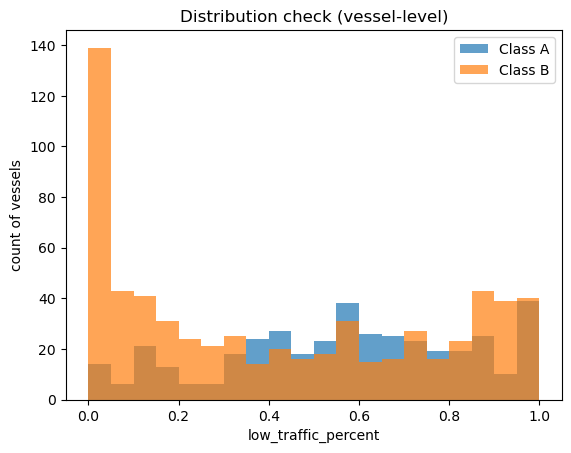

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(a, bins=20, alpha=0.7, label="Class A")
plt.hist(b, bins=20, alpha=0.7, label="Class B")
plt.xlabel("low_traffic_percent")
plt.ylabel("count of vessels")
plt.legend()
plt.title("Distribution check (vessel-level)")
plt.show()

In [5]:
from scipy import stats


tstat, pval = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
tstat, pval

(np.float64(7.907026768574145), np.float64(6.9980112529669485e-15))

### Decision

Compare **p-value** to **alpha = 0.05**.

- If p <= 0.05: reject  NULL (evidence of a difference).
- If p > 0.05: accept NULL (not enough evidence of a difference).

In [6]:
decision = "REJECT H0" if pval <= ALPHA else "FAIL TO REJECT H0"
print("alpha =", ALPHA)
print("n(Class A) =", len(a), " n(Class B) =", len(b))
print("Welch t-stat =", tstat)
print("p-value =", pval)
print("Decision:", decision)

alpha = 0.05
n(Class A) = 400  n(Class B) = 642
Welch t-stat = 7.907026768574145
p-value = 6.9980112529669485e-15
Decision: REJECT H0


## Regression model

Build a **logistic regression** model to predict whether a vessel is an "outlier".

**Label definition**
- outlier = 1 if the vessel is in the top 15% of low_traffic_percent
- outlier = 0 otherwise

**Why logistic?** The target is a **yes/no** label.


In [7]:

features = make_vessel_features(df)


model_df = features.merge(scores2[["MMSI", "low_traffic_percent"]], on="MMSI", how="inner")


cut = model_df["low_traffic_percent"].quantile(0.85)
model_df["is_outlier"] = (model_df["low_traffic_percent"] >= cut).astype(int)

model_df[["MMSI","low_traffic_percent","is_outlier"]].head(), model_df["is_outlier"].mean()

(        MMSI  low_traffic_percent  is_outlier
 0  155012139             0.083704           0
 1  209015000             0.772236           0
 2  210065000             0.448864           0
 3  210296000             0.511419           0
 4  210959000             0.573441           0,
 np.float64(0.15067178502879078))

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score, confusion_matrix

X = model_df[["n_points","mean_sog","std_sog","mean_cog","std_cog","lat_range","lon_range","time_span_minutes"]].copy()
y = model_df["is_outlier"].copy()


clf = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

proba = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]

roc_auc = roc_auc_score(y, proba)
ap = average_precision_score(y, proba)

roc_auc, ap

(np.float64(0.7404224693223938), np.float64(0.4889968321735152))

### Choosing a decision threshold

In the IC, we often prefer **high recall** (catch more true outliers),
even if we get more false alarms.

One simple approach:
- pick the threshold that gives **at least 80% recall**, and then report precision.

In [9]:
from sklearn.metrics import precision_score, recall_score

precision, recall, thresh = precision_recall_curve(y, proba)


target_recall = 0.80
idx = np.where(recall >= target_recall)[0]
if len(idx) == 0:
    chosen_t = 0.5
else:

    j = min(idx[-1], len(thresh)-1)
    chosen_t = float(thresh[j])

y_hat = (proba >= chosen_t).astype(int)

print("Chosen threshold =", chosen_t)
print("Precision =", precision_score(y, y_hat))
print("Recall =", recall_score(y, y_hat))
print("Confusion matrix:\n", confusion_matrix(y, y_hat))

Chosen threshold = 0.39681431296692593
Precision = 0.21686746987951808
Recall = 0.802547770700637
Confusion matrix:
 [[430 455]
 [ 31 126]]


### "Process used to ensure the model was properly fit."

- Built features at the **vessel level** (one row per MMSI).
- Used **Stratified 5-fold cross-validation** to estimate performance on unseen vessels.
- Handled class imbalance with `class_weight="balanced"`.
- Picked a decision threshold based on an operational goal (**recall >= 0.80**).